# Example run of Gradient Descent Algorithm on Forward Model.

## Prepare Notebook.

### Flags for Autoreload.

In [8]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Autoreload Environment.

In [9]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import Libraries.

In [18]:
from collections.abc import Collection
from datetime import datetime
from functools import partial
import logging
import os
import sys
import traceback
from typing import Callable
import uuid

import anndata as ad
import hydra
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import DictConfig, OmegaConf
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch

from labcompass.models import FlowMatching, FlowMatchingWithScore, FlowMap
from labcompass.utils import set_reproducibility
from labcompass.inverse import LossGuidedFlow

import scopt

### Registry for settings.

In [11]:
ROOT_DIR = "../../../../../../.."
NON_LINEARITIES_REGISTRY = {
    "identity": torch.nn.Identity,
    "relu": torch.nn.ReLU
}

### Configure Logging.

In [12]:
# 1. Configure the logging behavior
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout) # Ensures it goes to console
    ]
)
logger = logging.getLogger(__name__)


### Import Additional Modules.

In [13]:
# Import modules
sys.path.insert(0, os.path.join(ROOT_DIR, "shared_utils"))
from lambda_schedulers import schedulers_dict
from train_utils import resolve_omegaconf_to_dictionary
from experiment_utils import (
    create_dir,
    get_forward_model,
    query_forward_model,
    flatten_conf,
    get_transformed_data,
    get_target_dict,
    get_loss_fn,
)
from data_utils import get_protocol_tranformations
from plot_utils import plot_loss_history, plot_heatmap
from inverse_utils import loss_fn_factory, constraint_fn_factory, linear_scheduler_with_warmup


### Load Configurations.

In [14]:
with os.environ["REPO_ROOT"] = os.path.abspath("../../../../../..")

hydra.initialize(
    config_path="../../../../../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols",
            "sampling.mask_gradients=False"
        ]
    )
protocol_cols = config.annotation.protocol_columns
ndims = len(protocol_cols)

/tmp/ipykernel_1119788/3314667551.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Set Reproducibility.

In [15]:
# Set reproducibility
logger.info(f"Reproducibility set to {config.run.random_seed}")
set_reproducibility(config.run.random_seed)


[2026-05-29 11:21:06] - __main__: Reproducibility set to 42


## Load Stuff.

### Load Forward Model.

In [16]:
forward_model, (
    _,
    target_prediction_model
) = get_forward_model(config, logger=logger)
logger.info(f"Forward model ready!\n{forward_model}")
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()

[2026-05-29 11:21:08] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...


[2026-05-29 11:22:45] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=1024, out_features=128, bias=True)
          (1): Identity(

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=1024, out_features=128, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_encoder

### Load Data.

In [19]:
path_adata_full = "../../../../../../project_folder/output/loops/data/loop1/adata_full.h5ad"
adata_full = ad.read_h5ad(path_adata_full)
adata_full

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Fit Label Encoder for Target Variable.

In [20]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs[config.loss.cell_type_column].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

### Get Real Concentrations.

In [21]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_full.obs[protocol_cols].astype(float).values   # or use obs[protocol_columns].values
exp_nums = adata_full.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


## Prepare Potential.

### Get Loss Functions.

In [22]:
# Define loss function
logger.info(f"Preparing loss function (Cross-Entropy)...")
loss_fns = get_loss_fn(config)
logger.info(f"Loss function ready!\n{loss_fns}")


[2026-05-29 11:26:27] - __main__: Preparing loss function (Cross-Entropy)...
[2026-05-29 11:26:27] - __main__: Loss function ready!
{'cell_type': <function get_loss_fn.<locals>.<lambda> at 0x7fe2a099ff60>}


### Get Target Value.

In [23]:
# Define target for current cell type
logger.info(f"Preparing target value for cell type {config.sampling.target_cell_type}...")
target = get_target_dict(
    config,
    classes,
    config.loss.cell_type_column,
    forward_model.forward_model.device
)
logger.info(f"Target ready!\n{target}")


[2026-05-29 11:26:29] - __main__: Preparing target value for cell type HSCs...
[2026-05-29 11:26:36] - __main__: Target ready!
{'cell_type': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.]], device='cuda:0')}


### Initialize Non-Linearity.

In [24]:
# Initialize non linearity
logger.info(f"Initializing non linearity {config.non_linearity.non_linearity_id}...")
non_linearity_class = NON_LINEARITIES_REGISTRY.get(config.non_linearity.non_linearity_id, None)
if non_linearity_class is None:
    msg = f"Non linearity {config.non_linearity.non_linearity_id} not valid"
    raise ValueError(msg)
non_linearity = non_linearity_class(**resolve_omegaconf_to_dictionary(config.non_linearity.non_linearity_kwargs))
logger.info(f"Non linearity initialized!\n{non_linearity}")


[2026-05-29 11:26:38] - __main__: Initializing non linearity relu...
[2026-05-29 11:26:38] - __main__: Non linearity initialized!
ReLU()


### Prepare Loss.

In [25]:
# compile loss function
logger.info(f"Compiling final loss function for current cell type...")
compute_loss, noise = loss_fn_factory(
    loss_fns,
    config,
    target,
    non_linearity,
    forward_model,
)
logger.info(f"Loss function compiled!")


[2026-05-29 11:26:41] - __main__: Compiling final loss function for current cell type...
[2026-05-29 11:26:41] - __main__: Loss function compiled!


### Prepare Constraints.

In [26]:
# compile constraints
logger.info(f"Compiling constraints for current experiment...")
compute_constraints = constraint_fn_factory(config, forward_model.forward_model.device, get_protocol_tranformations)
logger.info(f"Constraints compiled!")

[2026-05-29 11:26:44] - __main__: Compiling constraints for current experiment...
[2026-05-29 11:26:44] - __main__: Constraints compiled!


### Define Potential Object.

In [47]:
class FWDPotential(scopt.potentials.BasePotential):
    def __init__(
        self,
        target,
        loss_fn: Callable[[torch.Tensor], torch.Tensor],
        penalties: Collection[Callable[[torch.Tensor], torch.Tensor]] | None = None,
        lambda_pen = 1.0,
    ):
        super().__init__()
        self._target = target
        self._loss_fn = loss_fn
        self._penalties = penalties if penalties is not None else []
        self._lambda_pen = lambda_pen
    
    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:
        loss = self._loss_fn(x)
        penalties = []
        for pen_fn in self._penalties:
            pen_val = pen_fn(x)
            penalties.append(pen_val)
        penalties = torch.stack(penalties, axis=0).sum(0)
        return loss + self._lambda_pen * penalties

potential = FWDPotential(
    target,
    compute_loss,
    compute_constraints,
    lambda_pen=0.0
)

## Optimize.

### Initialize Optimization Configurations.

In [48]:
# n_steps = 10_000
n_steps = 500
lr_scheduler = scopt.schedulers.LinearLR(n_steps, .1, 0.0)
# lr_scheduler = scopt.schedulers.ExponentialLR(n_steps, 1.0, 0.999)

### Check scheduler trajectory

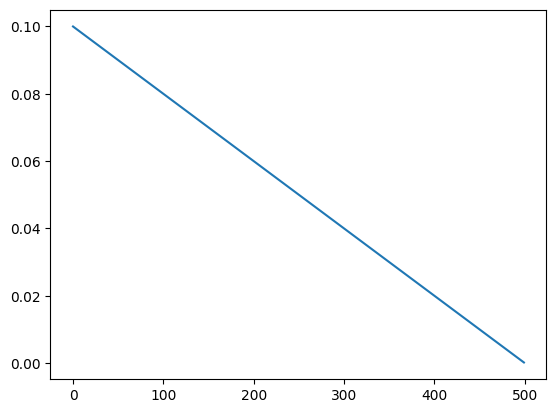

In [49]:
lr_steps = []
for step in range(n_steps):
    lr_steps.append(lr_scheduler(step))
plt.plot(lr_steps)

In [50]:
def init_distr(n_samples):
    n_samples, _ = n_samples
    idxs = np.random.choice(real_matrix.shape[0], size=n_samples)
    batch_matrix = real_matrix[idxs]
    batch_matrix = np.log1p(batch_matrix)
    return torch.from_numpy(batch_matrix)

### Initialize Optimizer.

In [51]:
gf = scopt.methods.EuclideanGradientFlow(
    potential,
    ndims,
    lr_scheduler=lr_scheduler,
    init_distr=init_distr,
)

### Sample.

In [52]:
return_loss = True
if return_loss:
    x1_samples, losses = gf.sample(10, return_loss=return_loss)
else:
    x1_samples = gf.samples(10, return_loss=return_loss)

In [40]:
x1_hat = x1_samples[-1].detach().cpu().numpy()

<Axes: >

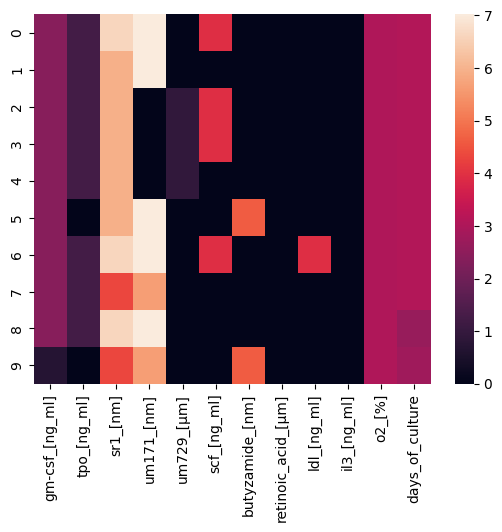

In [41]:
x0_hat = x1_samples[0].detach().cpu().numpy()
x0_hat = np.maximum(x0_hat, 0)
sns.heatmap(
    x0_hat, 
    xticklabels=protocol_cols
)

<Axes: >

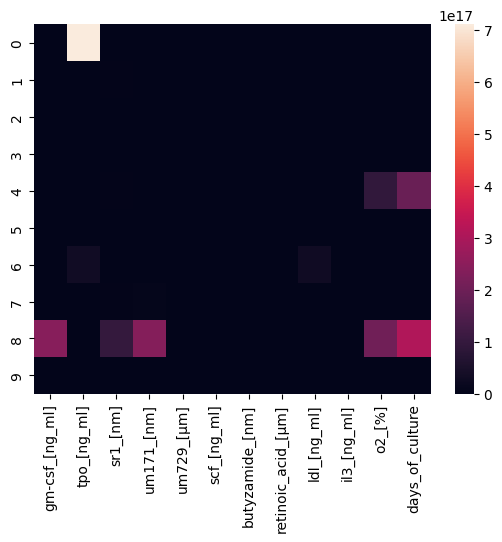

In [42]:
x1_hat = np.maximum(x1_hat, 0)
sns.heatmap(
    x1_hat, 
    xticklabels=protocol_cols
)

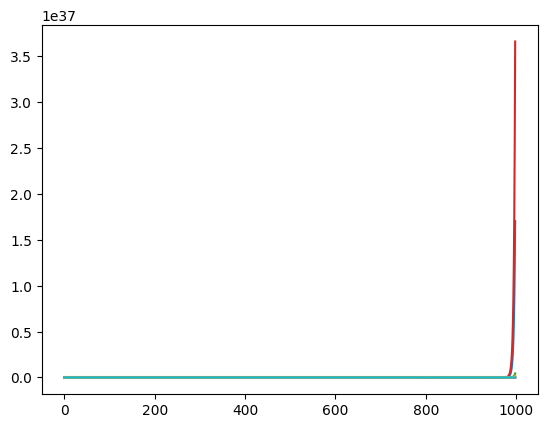

In [43]:
plt.plot(losses.detach().cpu().numpy())